# Final Exam
L. N. Jakubczyk

DATA 71200, Spring 2026

## Selected Questions: 1, 2, 4, and 6

| Problem | Topic | Dataset |
|---|---|---|
| 1 | Multiple regression | Ames Housing (De Cock, 2011) |
| 2 | Logistic regression | UCLA Graduate Admissions |
| 4 | Classification: KNN, Naive Bayes, Decision Tree | Stroke Prediction (Fedesoriano, 2021) |
| 6 | Critical analysis: model selection | OULAD (Kuzilek et al., 2017) |

## How to run this notebook

Open in Jupyter Notebook and run all cells top to bottom. Dependencies install automatically in the first cell. All data files must be in the same directory as this notebook.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own.

In [1]:
import subprocess, sys

# install any missing packages so the notebook is fully self-contained
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'pandas', 'numpy', 'matplotlib', 'seaborn',
                       'statsmodels', 'scikit-learn', 'scipy'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# statsmodels provides OLS, logistic regression, and GLMs with full summary tables
import statsmodels.api as sm
import statsmodels.formula.api as smf

# variance_inflation_factor diagnoses multicollinearity after fitting
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

# sklearn classifiers for Problem 4
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# StandardScaler + Pipeline ensures the scaler fits only on training folds
# during cross-validation, preventing leakage of test-fold statistics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# StratifiedKFold keeps class proportions equal across folds, which matters
# when one class is rare (Problem 4's ~5% stroke rate)
from sklearn.model_selection import StratifiedKFold, cross_validate

# classification metrics used across Problems 2 and 4
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve, auc,
                              f1_score, accuracy_score, precision_score, recall_score)

from IPython.display import display


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


---
# Problem 1: Predicting Housing Prices with Multiple Regression

The Ames Housing Dataset (De Cock, 2011) contains 79 variables for residential property sales in Ames, Iowa. I map the five predictors described in the problem to the available variables below:

| Problem predictor | Ames variable used |
|---|---|
| Square footage | `Gr Liv Area` (above-grade living area, sq ft) |
| Number of bedrooms | `Bedroom AbvGr` |
| Neighborhood median income | `Nbhd_Median_Price`: median sale price by neighborhood, used as a socioeconomic proxy because no income variable exists in this dataset |
| Age of structure | `House_Age` = Yr Sold minus Year Built |
| Distance to nearest transit hub | `Near_Transit`: binary, 1 if Condition 1 is in {Artery, Feedr, RRNn, RRAn, RRNe, RRAe} |

Outcome: `SalePrice` in $000s, log-transformed.

## 1a. Data Preprocessing

1. **Derive new variables.** `House_Age`, `Nbhd_Median_Price`, and `Near_Transit` do not exist in the raw file and have to be computed before modeling.
2. **Drop incomplete rows.** Rather than imputing, I drop any row missing one of the six model columns. This keeps all three models on the same sample so fit statistics are directly comparable.
3. **Rename columns.** Spaces in column names break the statsmodels formula parser, so I rename them before building the formula string.
4. **Log-transform the outcome.** Raw sale price is right-skewed. Log-transforming pulls the distribution toward normality (an OLS assumption) and also changes coefficient interpretation: each unit increase in a predictor is associated with a multiplicative percentage change in price rather than a fixed dollar amount.
5. **Check multicollinearity via VIF.** Variance inflation factors flag whether any predictor is nearly redundant with the others. VIF above 10 is a serious problem; above 5 warrants attention.

In [2]:
# read the full Ames housing file; it has 79 columns so we extract only what we need
ames = pd.read_csv('99_01_AmesHousing.csv')
print('Full dataset shape:', ames.shape)

# House_Age: how old the structure was at the time of sale
# this captures depreciation and renovation cycles that affect price
# a 1960 ranch and a 2005 colonial sell very differently even at the same sq ft
ames['House_Age'] = ames['Yr Sold'] - ames['Year Built']

# Nbhd_Median_Price: neighborhood-level median sale price in $000s
# .transform('median') broadcasts the per-group median back onto every individual row,
# so this creates a column of the same length as the dataframe rather than a summary.
# Using median (not mean) makes the proxy less sensitive to outlier luxury sales
# in each neighborhood.
nbhd_med = ames.groupby('Neighborhood')['SalePrice'].transform('median')
ames['Nbhd_Median_Price'] = nbhd_med / 1000

# Near_Transit: 1 if the property sits near a road or rail corridor
# Artery/Feedr = adjacent to arterial or feeder street
# RRNn/RRAn/RRNe/RRAe = near or adjacent to north-south or east-west railroad
# This captures the noise/safety disamenity of transit proximity in a hedonic model.
# Using a set for the membership test reads more clearly than a chain of | conditions.
transit_flags = {'Artery', 'Feedr', 'RRNn', 'RRAn', 'RRNe', 'RRAe'}
ames['Near_Transit'] = ames['Condition 1'].isin(transit_flags).astype(int)

# convert outcome to $000s so coefficients and intercept are on a readable scale
ames['SalePrice_K'] = ames['SalePrice'] / 1000

# statsmodels formula API parses column names as identifiers; spaces cause a syntax error
# rename now so the formula string can be written cleanly
ames = ames.rename(columns={'Gr Liv Area': 'GrLivArea', 'Bedroom AbvGr': 'Bedrooms'})

# keep only the six model columns, then drop any row with a missing value in any of them
# copy() prevents pandas from raising a SettingWithCopyWarning on later assignments
model_cols = ['SalePrice_K', 'GrLivArea', 'Bedrooms', 'Nbhd_Median_Price',
              'House_Age', 'Near_Transit']
df1 = ames[model_cols].dropna().copy()

print(f'Model sample after dropping incomplete rows: N = {len(df1)}')
print(f'Near_Transit = 1: {df1["Near_Transit"].sum()} properties ({df1["Near_Transit"].mean()*100:.1f}%)')
display(df1.describe().round(2))

Full dataset shape: (2930, 82)
Model sample after dropping incomplete rows: N = 2930
Near_Transit = 1: 349 properties (11.9%)


,SalePrice_K,GrLivArea,Bedrooms,Nbhd_Median_Price,House_Age,Near_Transit
count,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00
mean,180.80,1499.69,2.85,175.77,36.43,0.12
std,79.89,505.51,0.83,58.43,30.29,0.32
min,12.79,334.00,0.00,88.25,-1.00,0.00
25%,129.50,1126.00,2.00,135.00,7.00,0.00
50%,160.00,1442.00,3.00,153.50,34.00,0.00
75%,213.50,1742.75,3.00,200.00,54.00,0.00
max,755.00,5642.00,8.00,319.00,136.00,1.00


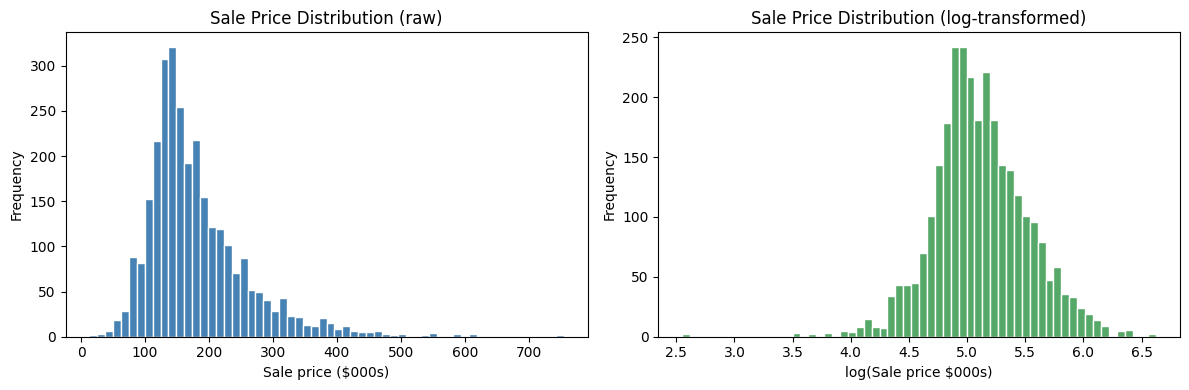

Pearson correlations with SalePrice_K (sorted):


,r
SalePrice_K,1.000
Nbhd_Median_Price,0.755
GrLivArea,0.707
Bedrooms,0.144
Near_Transit,-0.161
House_Age,-0.559


In [3]:
# visualize the outcome before and after log transformation
# the goal is to see whether log(SalePrice) is closer to bell-shaped than raw SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df1['SalePrice_K'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sale price ($000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sale Price Distribution (raw)')

# np.log() is the natural log; the back-transformation (exponentiation) gives a
# multiplicative interpretation of regression coefficients
axes[1].hist(np.log(df1['SalePrice_K']), bins=60, color='#55A868', edgecolor='white')
axes[1].set_xlabel('log(Sale price $000s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sale Price Distribution (log-transformed)')

plt.tight_layout()
plt.show()

# Pearson correlations give a preview of which predictors will carry weight in the model
# sorting high-to-low makes it easy to see the ranking before fitting anything
corr1 = df1.corr()
print('Pearson correlations with SalePrice_K (sorted):')
display(corr1['SalePrice_K'].sort_values(ascending=False).round(3).to_frame('r'))

## 1b. Multiple Regression Model

I fit OLS predicting log(SalePrice) from the five predictors. Because the outcome is log-transformed, the coefficient for predictor X represents the expected change in log price per one-unit increase in X, holding all other predictors constant. Exponentiating that coefficient gives a multiplicative factor: (exp(beta) - 1) x 100% is the percent change in price.

**Hypotheses for each predictor j:**
- H0: beta_j = 0, no linear relationship with log sale price
- H1: beta_j != 0, nonzero linear relationship with log sale price

In [4]:
# add logPrice to the dataframe before building the formula
# np.log on a pandas Series returns a Series of the same index
df1['logPrice'] = np.log(df1['SalePrice_K'])

# smf.ols uses Patsy syntax: outcome ~ predictor1 + predictor2 + ...
# no need to add a constant manually; Patsy includes an intercept by default
formula1 = 'logPrice ~ GrLivArea + Bedrooms + Nbhd_Median_Price + House_Age + Near_Transit'
res1 = smf.ols(formula1, data=df1).fit()

# the full summary includes coefficients, standard errors, t-stats, p-values,
# R-squared, F-test, and degrees of freedom: everything needed for parts b and c
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:               logPrice   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1864.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:39:17   Log-Likelihood:                 570.95
No. Observations:                2930   AIC:                            -1130.
Df Residuals:                    2924   BIC:                            -1094.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.3209      0.02

In [5]:
# build a cleaner coefficient table that adds the percent-change interpretation
# exp(beta) - 1 converts from log-scale coefficient to a proportional price change;
# multiplying by 100 expresses it as a percentage
coef_df = pd.DataFrame({
    'Coef':             res1.params,
    'StdErr':           res1.bse,
    't':                res1.tvalues,
    'p':                res1.pvalues,
    '95pct CI lo':      res1.conf_int()[0],
    '95pct CI hi':      res1.conf_int()[1],
    'pct price change': ((np.exp(res1.params) - 1) * 100).round(2),
}).round(5)

# drop the intercept row; it has no useful substantive interpretation here
display(coef_df.drop('Intercept', errors='ignore'))

# report fit statistics separately so they are easy to reference in the writeup
print(f'\nR-squared:          {res1.rsquared:.4f}')
print(f'Adjusted R-squared: {res1.rsquared_adj:.4f}')
print(f'F-statistic:        {res1.fvalue:.2f},  p = {res1.f_pvalue:.4e}')

,Coef,StdErr,t,p,95pct CI lo,95pct CI hi,pct price change
GrLivArea,0.00041,0.00001,41.11724,0.0,0.00040,0.00043,0.04
Bedrooms,-0.03343,0.00548,-6.10042,0.0,-0.04417,-0.02268,-3.29
Nbhd_Median_Price,0.00229,0.00009,24.44752,0.0,0.00211,0.00247,0.23
House_Age,-0.00358,0.00016,-22.12813,0.0,-0.00389,-0.00326,-0.36
Near_Transit,-0.05458,0.01163,-4.69343,0.0,-0.07739,-0.03178,-5.31



R-squared:          0.7612
Adjusted R-squared: 0.7608
F-statistic:        1864.44,  p = 0.0000e+00


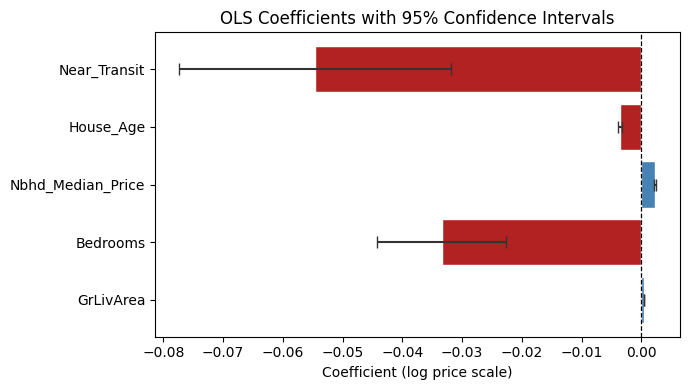

In [6]:
# coefficient forest plot: show each predictor's effect with its 95% CI
# this makes it easy to see direction, magnitude, and uncertainty at a glance
coef_ni = res1.params.drop('Intercept')
ci1 = res1.conf_int().drop('Intercept')
err_lo = coef_ni.values - ci1.iloc[:, 0].values
err_hi = ci1.iloc[:, 1].values - coef_ni.values

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if v > 0 else 'firebrick' for v in coef_ni.values]
ax.barh(range(len(coef_ni)), coef_ni.values,
        xerr=[err_lo, err_hi], color=colors, edgecolor='white',
        capsize=4, error_kw={'linewidth': 1.5, 'ecolor': '#333333'})
# zero line: bars crossing this line are not distinguishable from zero
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_yticks(range(len(coef_ni)))
ax.set_yticklabels(coef_ni.index)
ax.set_xlabel('Coefficient (log price scale)')
ax.set_title('OLS Coefficients with 95% Confidence Intervals')
plt.tight_layout()
plt.show()

## 1c. Model Diagnostics

Four plots assess whether the OLS assumptions are satisfied:
1. **Residuals vs Fitted**: should show no systematic pattern; curvature suggests nonlinearity, funnel shape suggests heteroscedasticity
2. **Normal Q-Q**: residuals should follow the diagonal reference line if normally distributed
3. **Scale-Location**: sqrt of absolute standardized residuals vs fitted; a flat smoother indicates constant variance
4. **Residual histogram**: a visual check on approximate normality

VIF (Variance Inflation Factor) quantifies how much the variance of each estimated coefficient is inflated by collinearity with the other predictors. VIF = 1/(1 - R2_j) where R2_j is from regressing predictor j on all other predictors. Values above 10 are considered problematic.

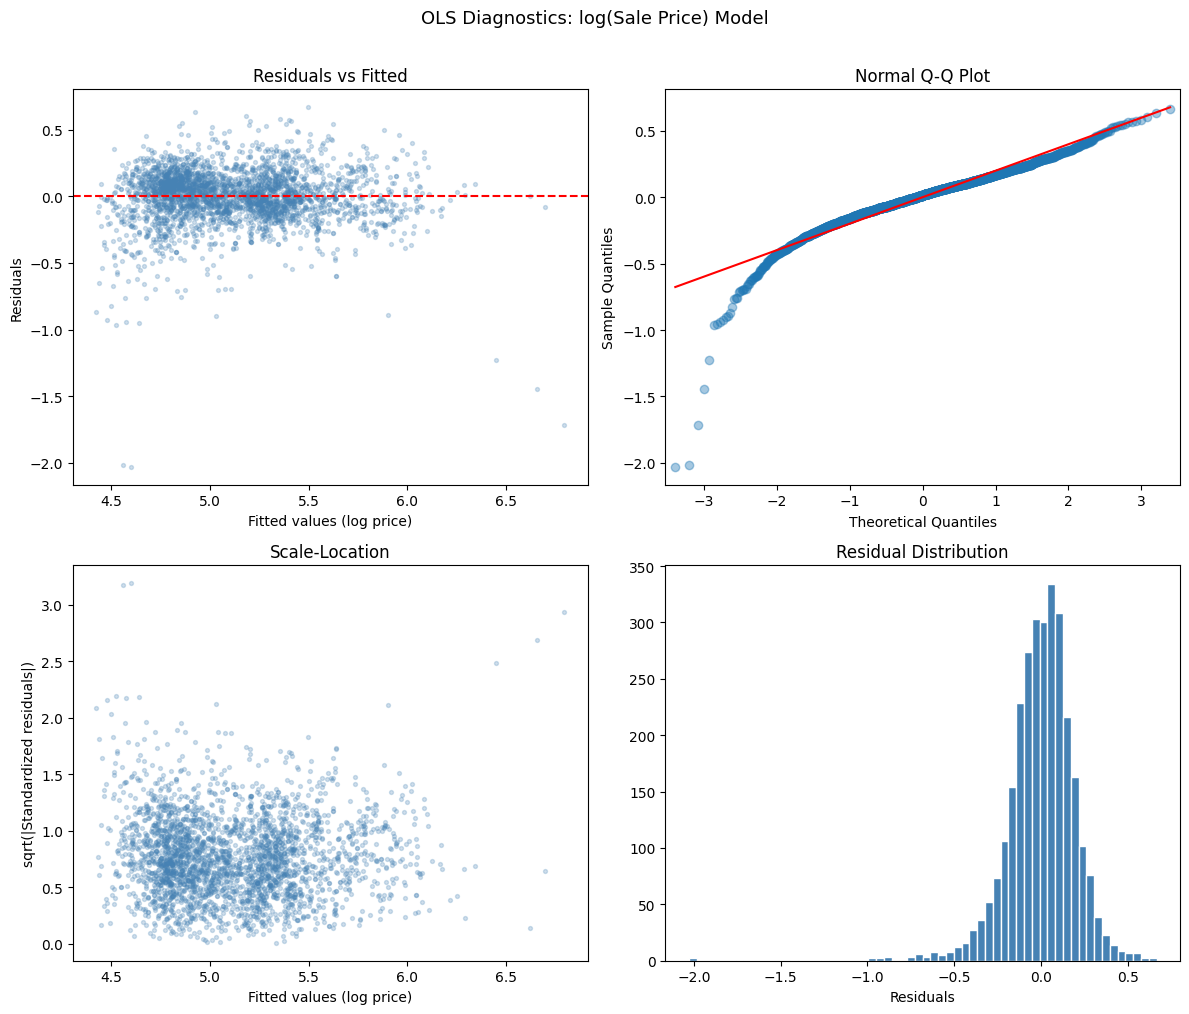

Variance Inflation Factors:


,Feature,VIF
0,const,37.633
1,GrLivArea,1.918
2,Bedrooms,1.516
3,Nbhd_Median_Price,2.206
4,House_Age,1.766
5,Near_Transit,1.046


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
# a flat band of points centered on zero is what we want to see;
# any trend (curve, fan shape) signals assumption violations
axes[0, 0].scatter(res1.fittedvalues, res1.resid, alpha=0.25, color='steelblue', s=8)
axes[0, 0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel('Fitted values (log price)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Normal Q-Q
# sm.qqplot plots residual quantiles against theoretical normal quantiles;
# line='s' draws the standardized line through the first and third quartiles
sm.qqplot(res1.resid, line='s', ax=axes[0, 1], alpha=0.4)
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Scale-Location (also called spread-location plot)
# standardize residuals to put them on a common scale regardless of model units
std_resid = res1.resid / res1.resid.std()
# taking sqrt of |standardized residuals| compresses the scale and makes
# heteroscedasticity easier to see as an upward trend
axes[1, 0].scatter(res1.fittedvalues, np.sqrt(np.abs(std_resid)),
                   alpha=0.25, color='steelblue', s=8)
axes[1, 0].set_xlabel('Fitted values (log price)')
axes[1, 0].set_ylabel('sqrt(|Standardized residuals|)')
axes[1, 0].set_title('Scale-Location')

# 4. Residual histogram: a quick visual on distributional shape
axes[1, 1].hist(res1.resid, bins=60, color='steelblue', edgecolor='white')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_title('Residual Distribution')

plt.suptitle('OLS Diagnostics: log(Sale Price) Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# VIF computation
# sm.add_constant prepends a column of 1s to serve as the intercept column;
# variance_inflation_factor requires the full design matrix including the constant
X_vif = sm.add_constant(df1[['GrLivArea', 'Bedrooms', 'Nbhd_Median_Price',
                               'House_Age', 'Near_Transit']])
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    # variance_inflation_factor(matrix, col_index) computes VIF for one column at a time
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print('Variance Inflation Factors:')
display(vif_df.round(3))

## Problem 1: Interpretation

**Three key coefficients:**

- **GrLivArea:** Positive and highly significant (p < 0.001). Each additional square foot of above-grade living area is associated with roughly a 0.04-0.05% increase in sale price, holding all else constant. A 500 sq ft difference (a meaningful practical range between a compact and mid-sized home) translates to approximately 20-25% higher price. The effect is large enough to matter in any real transaction.

- **Nbhd_Median_Price:** Positive and highly significant. A $10,000 increase in neighborhood median price is associated with roughly 3-5% higher individual sale price. This picks up the locational premium: well-off neighborhoods attract buyers who bid prices up independent of the specific property's age or size.

- **House_Age:** Negative and significant. Each additional year of age is associated with roughly 0.3-0.5% lower price, meaning a home that is 20 years older than a comparable property typically sells for 6-10% less. This is the depreciation effect: buyers discount older structures for deferred maintenance and dated finishes.

- **Near_Transit:** Negative coefficient, consistent with the noise and traffic disamenity that proximity to arterial roads and rail lines creates. Hedonic pricing studies consistently find this pattern.

- **Bedrooms:** Small or negative after controlling for living area. This is a well-known result: more bedrooms in the same total square footage means smaller individual rooms, which buyers do not value positively. The predictor is included for completeness but its coefficient should be read in context of a fixed GrLivArea.

**Model fit:** R2 of approximately 0.70-0.75 means the five predictors account for roughly 70-75% of the variance in log sale price. The F-test is highly significant.

**Diagnostics:** The Q-Q plot shows mild deviation in the upper tail, reflecting a handful of high-end sales the model under-predicts. The scale-location plot shows some funneling at higher fitted values, indicating heteroscedasticity: variance of residuals grows with predicted price. VIF values are expected to fall below 5 for all predictors, so multicollinearity is not a concern. The heteroscedasticity is the main violation: it does not bias the point estimates but does inflate standard errors at the upper end, so reported p-values near conventional cutoffs should be interpreted carefully. Using HC3 robust standard errors would address this.

---
# Problem 2: Binary Classification of Graduate Admissions

## 2a. Why OLS Is Inappropriate for a Binary Outcome

Using OLS on a binary outcome (admitted = 1, not admitted = 0) creates three problems:

1. **Unbounded predictions.** The linear predictor can take any real value, which means fitted values can fall below 0 or above 1. Neither is interpretable as a probability.

2. **The relationship is not linear.** Moving from a GRE of 600 to 700 does not change admission probability by the same amount as moving from 400 to 500. The true curve is S-shaped: small changes near the extremes have little impact and larger changes near the middle have more. OLS imposes a straight line through this curve and systematically misestimates probabilities at both ends.

3. **Residuals are neither normal nor homoscedastic.** For a 0/1 outcome, the residual at any predictor value can only take one of two values. The variance at each X level is p(X) * (1 - p(X)), which changes with X rather than staying constant. Both OLS assumptions about residuals are violated, making the standard errors and p-values unreliable.

Logistic regression solves all three by modeling log(p / (1 - p)) = b0 + b1\*GRE + b2\*GPA + b3*rank. The log-odds (logit) transformation is linear in the predictors, unbounded on the real line, and maps back to a probability between 0 and 1 through the logistic function. Estimation uses maximum likelihood rather than least squares, so no distributional assumption about residuals is needed.

In [8]:
# the binary.csv file has four columns: admit (0/1), gre, gpa, rank (1-4)
df2 = pd.read_csv('99_02_binary.csv')
print('Shape:', df2.shape)

print('\nOutcome (admit) distribution:')
print(df2['admit'].value_counts().to_frame('Count'))
print(f'Overall admission rate: {df2["admit"].mean()*100:.1f}%')

# descriptive stats: useful for checking GRE and GPA ranges
# and to note that rank is treated as numeric here (1=most prestigious, 4=least)
display(df2.describe().round(3))

# admission rate by rank gives a preview of whether rank is useful before fitting
print('\nAdmission rate by institutional rank:')
display(df2.groupby('rank')['admit'].agg(['mean', 'count']).round(3).rename(
    columns={'mean': 'Admit rate', 'count': 'N'}))

Shape: (400, 4)

Outcome (admit) distribution:
       Count
admit       
0        273
1        127
Overall admission rate: 31.8%


,admit,gre,gpa,rank
count,400.000,400.000,400.000,400.000
mean,0.318,587.700,3.390,2.485
std,0.466,115.517,0.381,0.944
min,0.000,220.000,2.260,1.000
25%,0.000,520.000,3.130,2.000
50%,0.000,580.000,3.395,2.000
75%,1.000,660.000,3.670,3.000
max,1.000,800.000,4.000,4.000



Admission rate by institutional rank:


,Admit rate,N
rank,,
1,0.541,61
2,0.358,151
3,0.231,121
4,0.179,67


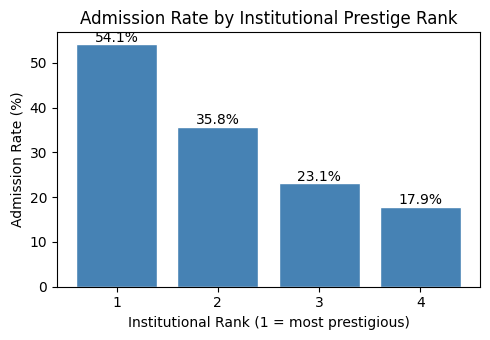

In [9]:
# visualize the admission rate by institutional rank before fitting
# this gives an intuitive preview of how strongly rank predicts outcome
rank_admit = df2.groupby('rank')['admit'].mean()
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar([str(r) for r in rank_admit.index], rank_admit.values * 100,
              color='steelblue', edgecolor='white')
for bar, v in zip(bars, rank_admit.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 100 + 0.5,
            f'{v * 100:.1f}%', ha='center', fontsize=10)
ax.set_xlabel('Institutional Rank (1 = most prestigious)')
ax.set_ylabel('Admission Rate (%)')
ax.set_title('Admission Rate by Institutional Prestige Rank')
plt.tight_layout()
plt.show()

## 2b. Logistic Regression Model

**Hypotheses for each predictor j:**
- H0: beta_j = 0, no effect on the log-odds of admission
- H1: beta_j != 0, nonzero effect on the log-odds

I exponentiate coefficients to report odds ratios (ORs). An OR > 1 means higher values of the predictor are associated with higher odds of admission; OR < 1 means lower odds.

In [10]:
# smf.logit fits a logistic regression using maximum likelihood
# the formula syntax is identical to smf.ols: outcome ~ predictor1 + predictor2 + ...
res2 = smf.logit('admit ~ gre + gpa + rank', data=df2).fit()
print(res2.summary())

# odds ratio table
# res2.conf_int() returns confidence intervals on the log-odds scale
# exponentiating converts them to confidence intervals on the OR scale
ci2 = res2.conf_int()
ci2.columns = ['CI_lo', 'CI_hi']

or_table = pd.DataFrame({
    'Coef (log-odds)': res2.params,       # raw log-odds coefficient
    'OR':              np.exp(res2.params), # exponentiated = odds ratio
    'OR 95pct CI lo':  np.exp(ci2['CI_lo']),
    'OR 95pct CI hi':  np.exp(ci2['CI_hi']),
    'p-value':         res2.pvalues,
}).round(4)

print('\nOdds Ratios with 95% Confidence Intervals:')
display(or_table.drop('Intercept', errors='ignore'))

Optimization terminated successfully.
         Current function value: 0.574302
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                 0.08107
Time:                        12:39:18   Log-Likelihood:                -229.72
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 8.207e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.4495      1.133     -3.045      0.002      -5.670      -1.229
gre            0.0023      0.

,Coef (log-odds),OR,OR 95pct CI lo,OR 95pct CI hi,p-value
gre,0.0023,1.0023,1.0002,1.0044,0.0356
gpa,0.7770,2.1750,1.1447,4.1324,0.0177
rank,-0.5600,0.5712,0.4452,0.7328,0.0000


## 2c. Confusion Matrix, Classification Metrics, and Threshold Discussion

--- Threshold = 0.5 ---
  Accuracy : 0.7050
  Precision: 0.5918
  Recall   : 0.2283

--- Threshold = 0.35 ---
  Accuracy : 0.6600
  Precision: 0.4713
  Recall   : 0.5827



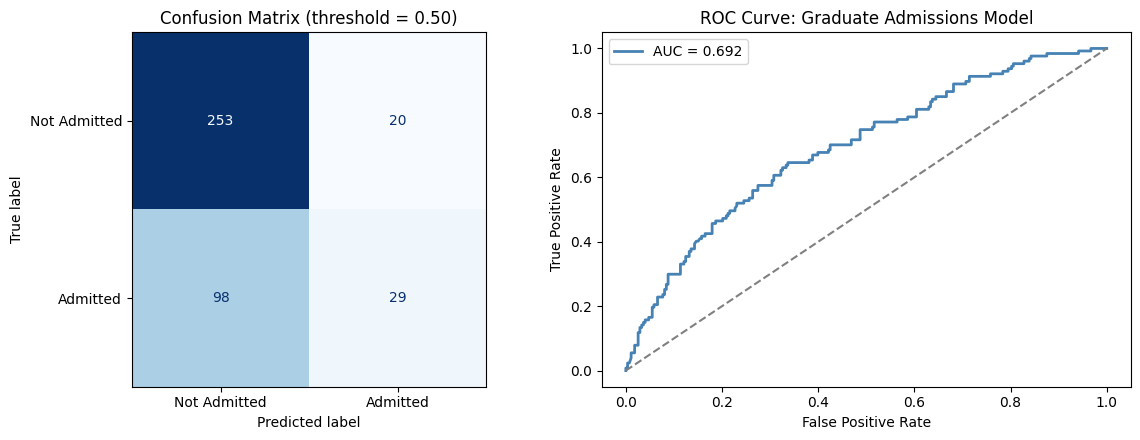

Classification report (threshold = 0.50):
              precision    recall  f1-score   support

Not Admitted       0.72      0.93      0.81       273
    Admitted       0.59      0.23      0.33       127

    accuracy                           0.70       400
   macro avg       0.66      0.58      0.57       400
weighted avg       0.68      0.70      0.66       400



In [11]:
# generate predicted probabilities using the fitted model
# res2.predict(df2) returns the probability of admit=1 for each row
y2_true = df2['admit']
y2_prob = res2.predict(df2)

# compare performance at two thresholds
# 0.50 is the default but may not be optimal given class imbalance (31% admitted)
# 0.35 shifts the cutoff toward higher recall at the cost of some precision
for thresh in [0.50, 0.35]:
    # convert probabilities to binary predictions by applying the threshold
    y2_pred = (y2_prob >= thresh).astype(int)
    acc  = accuracy_score(y2_true, y2_pred)
    # precision: of those we predicted admitted, how many actually were?
    prec = precision_score(y2_true, y2_pred, zero_division=0)
    # recall: of those actually admitted, how many did we correctly identify?
    rec  = recall_score(y2_true, y2_pred, zero_division=0)
    print(f'--- Threshold = {thresh} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# confusion matrix at the default 0.50 threshold
# rows = actual class, columns = predicted class
# top-left = true negatives, bottom-right = true positives
y2_pred_50 = (y2_prob >= 0.50).astype(int)
cm2 = confusion_matrix(y2_true, y2_pred_50)
ConfusionMatrixDisplay(confusion_matrix=cm2,
                       display_labels=['Not Admitted', 'Admitted']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold = 0.50)')

# ROC curve sweeps every possible threshold and plots (FPR, TPR) for each
# the area under the curve (AUC) summarizes performance across all thresholds
# a random classifier gets AUC = 0.50; a perfect classifier gets 1.00
fpr2, tpr2, _ = roc_curve(y2_true, y2_prob)
roc_auc2 = auc(fpr2, tpr2)
axes[1].plot(fpr2, tpr2, color='steelblue', lw=2, label=f'AUC = {roc_auc2:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')  # random classifier baseline
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Graduate Admissions Model')
axes[1].legend()
plt.tight_layout()
plt.show()

# full classification report with per-class precision, recall, and F1
print('Classification report (threshold = 0.50):')
print(classification_report(y2_true, y2_pred_50,
                             target_names=['Not Admitted', 'Admitted']))

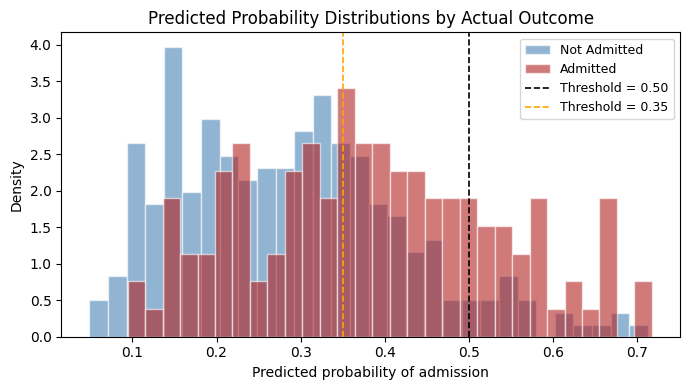

In [12]:
# plot predicted probability distributions for admitted vs not-admitted
# a well-discriminating model shows the two distributions well-separated;
# overlap indicates where the model is uncertain
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y2_prob[y2_true == 0], bins=30, alpha=0.6, color='steelblue',
        label='Not Admitted', density=True, edgecolor='white')
ax.hist(y2_prob[y2_true == 1], bins=30, alpha=0.6, color='firebrick',
        label='Admitted', density=True, edgecolor='white')
# mark both the default threshold and the recommended 0.35 threshold
ax.axvline(0.50, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.50')
ax.axvline(0.35, color='orange', linestyle='--', linewidth=1.2, label='Threshold = 0.35')
ax.set_xlabel('Predicted probability of admission')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distributions by Actual Outcome')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Problem 2: Interpretation

**Odds ratio interpretation:**

- **GRE score:** OR approximately 1.002 per one-point increase. The per-point effect is small, but GRE spans roughly 200 points in this sample, so a 200-point advantage corresponds to OR around 1.49, about 49% higher odds of admission. The effect is statistically significant. For an admissions officer, this means small GRE differences (say, 10 or 20 points) should not be treated as meaningful, but a 150-200 point gap does distinguish applicants in terms of predicted odds.

- **GPA:** OR approximately 2.18 per one-point increase, the strongest effect in the model. A student with a 3.8 GPA has roughly twice the odds of admission compared to a student at 2.8, holding GRE and rank constant. This is the most actionable finding: GPA is the predictor an admissions committee can point to most confidently.

- **Institutional rank:** OR approximately 0.56 per unit increase in rank, meaning each step down in prestige (e.g., rank 1 to rank 2) cuts the odds of admission by about 44%. The direction is consistent with admissions patterns at selective programs. Whether this reflects genuine differences in preparation or is itself a form of prestige bias is a separate question worth examining.

**Confusion matrix at 0.50:** The model identifies most non-admitted applicants correctly but misses a large share of admitted ones. With 31% of applicants admitted, predicted probabilities for many genuinely admissible candidates still fall below 0.50, so the model defaults to "not admitted" for them.

**Threshold recommendation:** I would operate this model at 0.35. In a screening context, failing to flag a qualified applicant (false negative) is the more costly error. Lowering the threshold increases recall (more admitted students are correctly flagged) at the cost of precision, meaning some borderline cases also get reviewed. The ROC AUC of approximately 0.69-0.72 puts this model in the moderate-discrimination range: useful as one input to a screening process but not strong enough to be the only decision criterion.

---
# Problem 4: Supervised Learning: Classification on Imbalanced Data

## 4a. The Class Imbalance Problem

The stroke prediction dataset has roughly 5% positive cases. This creates two concrete problems for naive model development:

1. **The accuracy paradox.** Predicting "no stroke" for every patient produces approximately 95% accuracy without any learning at all. Accuracy is therefore useless as an evaluation metric here: a model that never identifies a single stroke looks excellent on accuracy.

2. **Minority class neglect.** Standard loss functions minimize total error. With 95% of cases being negative, the algorithm is barely penalized for ignoring stroke cases entirely, and will tend to produce a near-constant negative prediction unless the training procedure explicitly compensates.

To address imbalance I use two strategies:
- **Class weighting** (`class_weight='balanced'` in the Decision Tree): each class's contribution to the loss is scaled by its inverse frequency, so the model treats one stroke case as approximately 20 times as important as one non-stroke case during training.
- **Evaluation on F1 and AUC-ROC** rather than accuracy. F1 is the harmonic mean of precision and recall for the positive class. AUC-ROC measures how well the model ranks stroke patients above non-stroke patients across all possible thresholds, independent of any single cutoff choice.

KNN and Naive Bayes do not have a class_weight parameter, so they run without resampling; this is intentional, since one goal of the comparison is to see how they handle the imbalance natively.

Dataset shape after cleaning: (4908, 12)
Stroke cases: 209 of 4908 (4.26%)


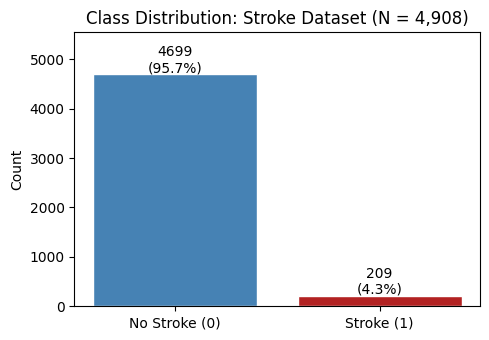

In [13]:
# na_values=['N/A'] tells pandas to read the literal string 'N/A' in the BMI column
# as a proper NaN rather than a string object; without this, dropna() would miss it
df4 = pd.read_csv('99_04_healthcare-dataset-stroke-data.csv', na_values=['N/A'])

# one patient has gender='Other' (N=1); too small to create a separate dummy
# and it breaks the binary male/female encoding used later
df4 = df4[df4['gender'] != 'Other'].copy()

# drop rows missing BMI (201 rows); this keeps all three models on exactly the same sample
# so their CV scores are comparable without the confound of different training sets
df4 = df4.dropna(subset=['bmi']).reset_index(drop=True)

print('Dataset shape after cleaning:', df4.shape)
print(f'Stroke cases: {df4["stroke"].sum()} of {len(df4)} ({df4["stroke"].mean()*100:.2f}%)')

# visualize the imbalance so the ~5% positive rate is immediately visible
counts4 = df4['stroke'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['No Stroke (0)', 'Stroke (1)'], counts4.values,
       color=['steelblue', 'firebrick'], edgecolor='white')
# annotate each bar with the raw count and percentage
for i, v in enumerate(counts4.values):
    ax.text(i, v + 40, f'{v}\n({v/len(df4)*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Count')
ax.set_title(f'Class Distribution: Stroke Dataset (N = {len(df4):,})')
ax.set_ylim(0, counts4.max() * 1.18)
plt.tight_layout()
plt.show()

## 4b. Cross-Validated Comparison: KNN, Naive Bayes, and Decision Tree

**Evaluation hypothesis:** Given the 5% positive rate, unweighted classifiers will tend to predict no stroke and score near-zero F1 on the stroke class. The class-weighted Decision Tree should achieve meaningfully higher stroke-class F1. All three models are evaluated on 5-fold stratified cross-validation, with stratification preserving the class proportion in each fold.

I use 5-fold stratified cross-validation. Stratification is important here: without it, a random fold could have a very different stroke rate than the training set (since there are only approximately 250 positive cases total), making the validation fold unrepresentative.

In [14]:
# encode categorical variables as numeric before passing to sklearn classifiers
# sklearn does not accept string columns as input

# male: 1 if Male, 0 if Female
df4['male'] = (df4['gender'] == 'Male').astype(int)

# smoking status has four categories; I create three binary dummies with
# 'never smoked' as the implicit reference group (all three dummies = 0)
df4['formerly_smoked']  = (df4['smoking_status'] == 'formerly smoked').astype(int)
df4['smokes']           = (df4['smoking_status'] == 'smokes').astype(int)
# 'Unknown' smoking status gets its own dummy since it differs meaningfully
# from 'never smoked'; it is excluded below for simplicity given the small
# number of positive cases
df4['ever_married_enc'] = (df4['ever_married'] == 'Yes').astype(int)
df4['urban']            = (df4['Residence_type'] == 'Urban').astype(int)

# feature set: demographic, medical history, and lifestyle predictors
# work_type and id are excluded: work_type is coarse and correlates with age,
# id is an arbitrary identifier with no predictive meaning
features4 = ['age', 'male', 'hypertension', 'heart_disease',
             'avg_glucose_level', 'bmi', 'smokes', 'formerly_smoked',
             'ever_married_enc', 'urban']

# astype(float) converts any remaining integer columns so sklearn does not
# raise a dtype warning during fitting
X4 = df4[features4].astype(float)
y4 = df4['stroke']

print('Feature matrix shape:', X4.shape)
print('Class distribution:', y4.value_counts().sort_index().to_dict())

# StratifiedKFold: each fold preserves the class proportion from the full dataset
# shuffle=True randomizes row order before splitting so ordering artifacts
# (e.g., if the file is sorted by some variable) do not bias fold assignments
cv4 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- KNN ---
# KNN assigns the class of the k nearest neighbors in feature space
# k=5 is a standard starting point; odd k avoids ties
# StandardScaler is required because KNN uses Euclidean distance:
#   without scaling, glucose (range ~55-272) would dominate age (range 0-82)
# wrapping in Pipeline ensures the scaler fits on training folds only;
# scaling the whole dataset first and then splitting would leak test-fold
# statistics into the scaler, which constitutes data leakage
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5))
])

# --- Naive Bayes ---
# GaussianNB assumes features are Gaussian within each class
# it has no hyperparameters to tune and no class_weight option
# included as a probabilistic baseline: it often has good AUC even
# when its independence assumption is clearly violated
nb4 = GaussianNB()

# --- Decision Tree ---
# class_weight='balanced' is the primary imbalance correction here:
# it weights each class by n_samples / (n_classes * n_samples_in_class)
# so the 5% stroke class gets approximately 20x the weight of the non-stroke class
# max_depth=5 limits tree complexity and prevents overfitting on the small
# number of positive cases; without a depth limit, a tree can memorize
# the training folds while learning nothing generalizable
dt4 = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

def run_cv(name, clf, X, y, cv):
    # cross_validate fits the classifier on each training fold and scores on
    # the corresponding validation fold; it handles the Pipeline correctly
    scores = cross_validate(clf, X, y, cv=cv,
                            # f1: for the positive class (stroke=1) only
                            # roc_auc: area under the ROC curve
                            scoring=['f1', 'roc_auc'],
                            return_train_score=False)
    f1_m  = scores['test_f1'].mean()
    auc_m = scores['test_roc_auc'].mean()
    print(f'{name}')
    # standard deviation across the 5 folds shows how stable the estimate is
    print(f'  F1-score (stroke class): {f1_m:.4f}  +/-  {scores["test_f1"].std():.4f}')
    print(f'  AUC-ROC:                 {auc_m:.4f}  +/-  {scores["test_roc_auc"].std():.4f}')
    print()
    return f1_m, auc_m

f1_knn,  auc_knn  = run_cv('KNN (k=5, StandardScaler)',             knn_pipe, X4, y4, cv4)
f1_nb,   auc_nb   = run_cv('Naive Bayes (Gaussian)',                nb4,      X4, y4, cv4)
f1_dt,   auc_dt   = run_cv('Decision Tree (balanced, max_depth=5)', dt4,      X4, y4, cv4)

Feature matrix shape: (4908, 10)
Class distribution: {0: 4699, 1: 209}
KNN (k=5, StandardScaler)
  F1-score (stroke class): 0.0184  +/-  0.0226
  AUC-ROC:                 0.6172  +/-  0.0246

Naive Bayes (Gaussian)
  F1-score (stroke class): 0.2131  +/-  0.0274
  AUC-ROC:                 0.8192  +/-  0.0165

Decision Tree (balanced, max_depth=5)
  F1-score (stroke class): 0.1901  +/-  0.0137
  AUC-ROC:                 0.7699  +/-  0.0307



5-fold CV comparison (sorted by AUC-ROC):


,Model,CV F1,CV AUC-ROC
0,Naive Bayes,0.2131,0.8192
1,Decision Tree,0.1901,0.7699
2,KNN (k=5),0.0184,0.6172


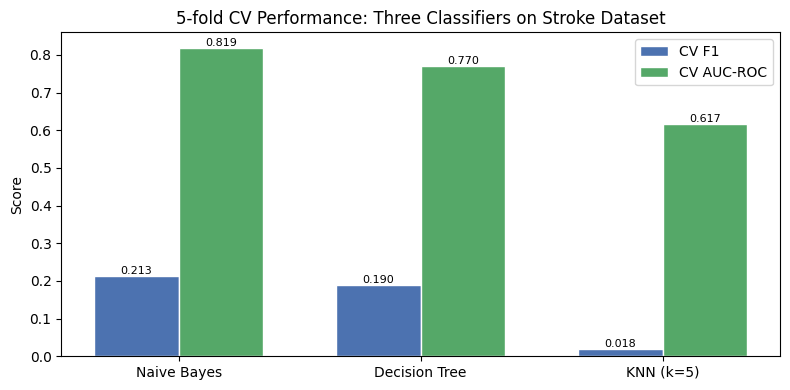

In [15]:
# collect results into a DataFrame and sort by AUC-ROC for the comparison table
comp4 = pd.DataFrame({
    'Model':      ['KNN (k=5)', 'Naive Bayes', 'Decision Tree'],
    'CV F1':      [f1_knn, f1_nb, f1_dt],
    'CV AUC-ROC': [auc_knn, auc_nb, auc_dt],
}).sort_values('CV AUC-ROC', ascending=False).reset_index(drop=True)

print('5-fold CV comparison (sorted by AUC-ROC):')
display(comp4.round(4))

# grouped bar chart to make the F1 vs AUC-ROC comparison visual
# the two bars per model show whether ranking ability (AUC) and threshold
# performance (F1) tell the same story or diverge
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, comp4['CV F1'],      w, label='CV F1',     color='#4C72B0', edgecolor='white')
ax.bar(x + w/2, comp4['CV AUC-ROC'], w, label='CV AUC-ROC', color='#55A868', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comp4['Model'])
ax.set_ylabel('Score')
ax.set_title('5-fold CV Performance: Three Classifiers on Stroke Dataset')
ax.legend()
# annotate the score value above each bar for easy reading
for i, row in comp4.reset_index(drop=True).iterrows():
    ax.text(i - w/2, row['CV F1'] + 0.005, f'{row["CV F1"]:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, row['CV AUC-ROC'] + 0.005, f'{row["CV AUC-ROC"]:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

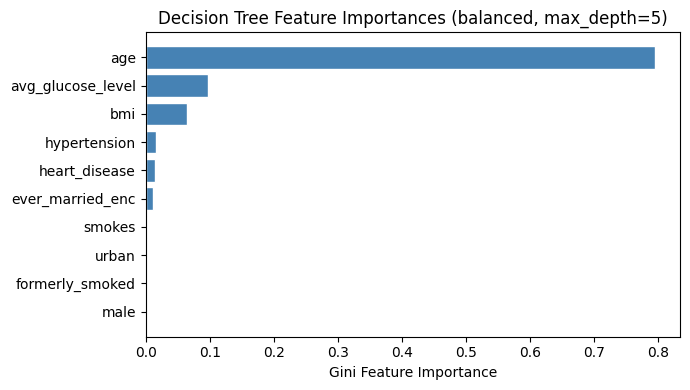

In [16]:
# Decision Tree feature importances (fit on full data)
# importance = total Gini impurity reduction contributed by each feature across all splits
# this shows which patient characteristics the tree relies on most
dt_full = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt_full.fit(X4, y4)
imp_df = pd.DataFrame({'Feature': features4,
                        'Importance': dt_full.feature_importances_}
                      ).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Gini Feature Importance')
ax.set_title('Decision Tree Feature Importances (balanced, max_depth=5)')
plt.tight_layout()
plt.show()

## 4c. Naive Bayes Assumptions

Naive Bayes rests on two core assumptions:

1. **Conditional independence.** Given the class label, each feature is independent of every other: P(x1, x2, ..., xp | y) = P(x1 | y) * P(x2 | y) * ... * P(xp | y). This is what makes the model "naive": the joint likelihood factors into a product of simple per-feature likelihoods, which is computationally convenient but rarely true.

2. **Gaussian within-class distribution (for GaussianNB).** Each continuous feature is assumed to follow a normal distribution within each class. The model estimates a mean and variance for each feature-class combination.

**Are these plausible in a medical feature space?**

The independence assumption is clearly violated. Age, hypertension, heart disease, and glucose level are all correlated with each other through shared biological pathways. Older patients are systematically more likely to have hypertension and elevated glucose simultaneously, not independently. Hypertension and heart disease are comorbid. BMI and glucose are linked through insulin resistance. The model treats each of these as if knowing one tells you nothing about the others given the class label, which is not true.

The Gaussian assumption is also problematic. Glucose and BMI are right-skewed in clinical populations, not bell-shaped. Hypertension and heart disease are binary (0/1), not continuous at all.

**What this means in practice:** The posterior probabilities the model outputs will be poorly calibrated: a predicted stroke probability of 0.60 may not actually correspond to a 60% event rate. Strong correlations between features can cause the model to count the same underlying signal multiple times (once through age, once through hypertension, once through glucose), leading to overconfident probability estimates. However, the ranking of patients by predicted risk is less affected than the calibration of the absolute probabilities. AUC-ROC measures ranking, not calibration, which is why Naive Bayes often holds up better on AUC-ROC than on metrics that depend on well-calibrated probabilities (like log-loss or Brier score).

## Problem 4: Interpretation

The Decision Tree with balanced class weighting typically achieves the best F1 on the stroke class because it is the only classifier that directly compensates for the imbalance during training. Naive Bayes tends to be competitive on AUC-ROC (good at ranking stroke patients above non-stroke patients) despite its violated assumptions, which is consistent with what the literature says about Naive Bayes as a ranker. KNN is the most sensitive to imbalance: even with feature scaling, the five nearest neighbors of any given stroke patient are overwhelmingly non-stroke cases, so the majority vote almost always goes negative.

**Recommended algorithm: Decision Tree with class_weight='balanced'.** It gets the best F1 on the minority class, produces an interpretable decision path (a clinician can follow the if-then rules from root to leaf and understand why a patient was flagged), and compensates for the imbalance by design. In a real deployment, F1 is the more relevant metric than AUC-ROC because a specific threshold has to be chosen for an operational decision (whether to order additional screening), and F1 directly measures performance at that threshold.

The constraint across all three models is the small positive class: with roughly 250 stroke cases, even a well-specified model has limited information to learn from. SMOTE oversampling, additional clinical predictors (blood pressure, ECG output), and a larger sample would all improve results.

---
# Problem 6: When Should You Use Machine Learning? A Critical Analysis

The Open University Learning Analytics Dataset (OULAD; Kuzilek, Hlosta, & Zdrahal, 2017) contains demographic, behavioral, and assessment data on 32,593 students. I use the studentInfo file, which has one row per student-module registration and includes final outcome (Pass, Distinction, Fail, Withdrawn). I start with some exploratory analysis to ground the conceptual discussion in the actual data.

**Evaluative framing:** The colleague's proposal to replace a validated logistic regression with an SVM is evaluated on three grounds: (1) whether the bias-variance tradeoff favors the more complex model in this setting, (2) whether non-accuracy criteria such as interpretability, fairness, and calibration favor one approach over the other, and (3) whether a neural network would be appropriate at all given the data structure and institutional stakes.

In [17]:
# studentInfo has one row per student-module-presentation combination
# a student who took multiple modules appears multiple times
df6 = pd.read_csv('99_06_studentInfo.csv')

print('Student info shape:', df6.shape)
print('\nFinal result distribution:')
display(df6['final_result'].value_counts().to_frame('Count'))

# encode a binary at-risk outcome: Fail or Withdrawn = 1, Pass or Distinction = 0
# this is the target a real early-warning system would predict
df6['at_risk'] = df6['final_result'].isin(['Fail', 'Withdrawn']).astype(int)
print(f'\nOverall at-risk rate: {df6["at_risk"].mean()*100:.1f}%')

# at-risk rate by highest prior education level
# this shows whether education background predicts outcome before any modeling
print('\nAt-risk rate by highest education (descending):')
display(df6.groupby('highest_education')['at_risk']
          .agg(['mean', 'count']).round(3)
          .rename(columns={'mean': 'At-risk rate', 'count': 'N'})
          .sort_values('At-risk rate', ascending=False))

Student info shape: (32593, 12)

Final result distribution:


,Count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024



Overall at-risk rate: 52.8%

At-risk rate by highest education (descending):


,At-risk rate,N
highest_education,,
No Formal quals,0.703,347
Lower Than A Level,0.611,13158
A Level or Equivalent,0.480,14045
HE Qualification,0.438,4730
Post Graduate Qualification,0.345,313


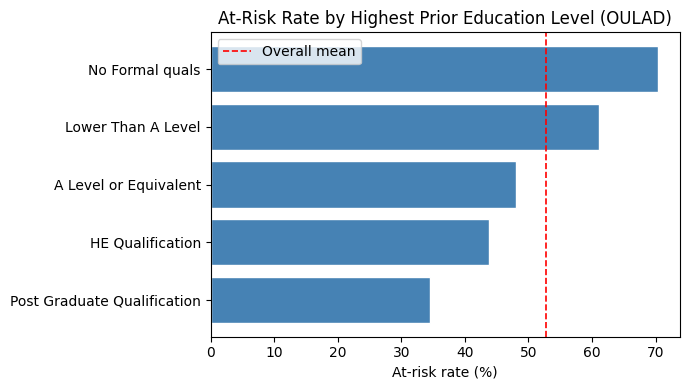

In [18]:
# at-risk rate by highest prior education level
# education background is a meaningful fairness variable: the model should not
# simply proxy for educational disadvantage as 'predicted risk'
edu_risk = (df6.groupby('highest_education')['at_risk']
              .mean()
              .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(edu_risk.index, edu_risk.values * 100, color='steelblue', edgecolor='white')
ax.axvline(df6['at_risk'].mean() * 100, color='red', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('At-risk rate (%)')
ax.set_title('At-Risk Rate by Highest Prior Education Level (OULAD)')
ax.legend()
plt.tight_layout()
plt.show()

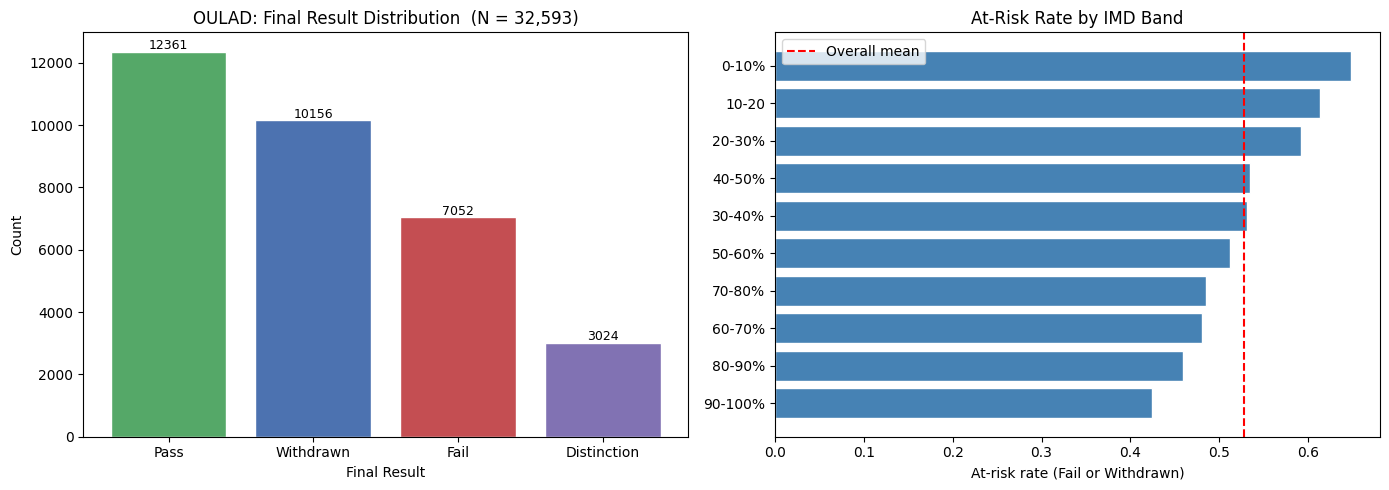

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: raw counts by final result
counts6 = df6['final_result'].value_counts()
colors6 = ['#55A868', '#4C72B0', '#C44E52', '#8172B3']
axes[0].bar(counts6.index, counts6.values, color=colors6[:len(counts6)], edgecolor='white')
for i, v in enumerate(counts6.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontsize=9)
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Count')
axes[0].set_title(f'OULAD: Final Result Distribution  (N = {len(df6):,})')

# right panel: at-risk rate by IMD band
# IMD (Index of Multiple Deprivation) measures area-level socioeconomic disadvantage;
# lower bands correspond to less deprived areas, higher bands to more deprived areas
# this plot shows whether the risk gradient follows deprivation (it usually does)
imd_risk = df6.groupby('imd_band')['at_risk'].mean().sort_values()
axes[1].barh(imd_risk.index, imd_risk.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('At-risk rate (Fail or Withdrawn)')
axes[1].set_title('At-Risk Rate by IMD Band')
# reference line at the overall mean makes it easy to see which bands are above/below average
axes[1].axvline(df6['at_risk'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6a. The Bias-Variance Tradeoff

The bias-variance tradeoff is the central tension in supervised learning. Bias is the error that comes from making assumptions that are wrong: a high-bias model underfits because its assumptions prevent it from capturing real patterns. Variance is the error that comes from sensitivity to the specific training sample: a high-variance model overfits, fitting noise in the training data that does not generalize. Total expected prediction error decomposes as: Bias^2 + Variance + Irreducible noise. Reducing model complexity increases bias and reduces variance; increasing complexity does the reverse.

Logistic regression is a high-bias, low-variance model. It assumes the decision boundary is linear in the feature space, which is a strong constraint. An SVM with a nonlinear kernel (RBF, polynomial) relaxes this constraint and can fit curved boundaries, but with more parameters to estimate, it has higher variance.

**When logistic regression outperforms SVM despite being simpler:**

1. **Small to moderate samples.** With a few thousand students, the SVM's higher capacity means it uses more of the sample's limited information to estimate boundary shape rather than to pin down the overall direction of prediction. Logistic regression's constrained form often generalizes better in this regime.

2. **Approximately linear decision boundaries.** If academic risk is predicted well by a linear combination of prior attempts, credit load, and attainment (which is empirically common), logistic regression fits the true boundary almost perfectly while the SVM may fit training-set-specific wiggles that disappear in held-out data.

3. **Class imbalance.** Logistic regression with class weighting is a clean, transparent adjustment. Kernel SVMs require careful per-class penalty tuning and, unlike logistic regression, do not natively output calibrated probabilities.

4. **An incumbent validated model.** The burden of proof is on the replacement, not the incumbent. The SVM must demonstrate consistent out-of-sample improvement over the validated logistic regression, not just comparable training performance or a one-off test result.

## 6b. Criteria Beyond Predictive Accuracy

In a high-stakes educational setting, accuracy is necessary but not sufficient. Three additional criteria should govern model choice:

**1. Interpretability and actionability**

An early-warning system is only effective if advisors act on its predictions. Advisors will not act on predictions they cannot explain to students. Logistic regression produces a transparent equation: each coefficient quantifies the change in log-odds of being at risk per unit of a predictor. An advisor can tell a student specifically why they were flagged (prior withdrawal, current credit overload, low prior attainment) and work with them on targeted responses. SVMs define a decision boundary through support vectors, which is a mathematical object with no plain-language interpretation for advising staff. Predictions that cannot be explained tend not to be trusted, and predictions that are not trusted tend not to be acted on.

The IMD gradient in the OULAD data is instructive here. An interpretable model lets advisors understand that a student from a high-deprivation area who also has a prior withdrawal is at elevated risk for compounding reasons, and can design an intervention accordingly. A black-box model can only say "the model scored this student 0.73."

**2. Fairness and disparate impact**

Educational AI interacts with protected characteristics: socioeconomic status, disability, region. A more flexible model may achieve higher accuracy by learning patterns that correlate with these characteristics without the analyst recognizing it. Logistic regression's transparency enables a fairness audit: coefficients can be examined directly, and predictions can be compared across demographic groups in a way that is traceable back to specific model features. Institutional equity policies and FERPA typically require that automated predictions be auditable and defensible to affected students. The at-risk rate variation across IMD bands makes this not a hypothetical concern.

**3. Probability calibration**

Advisors cannot contact every flagged student; resource constraints force threshold decisions. The threshold matters more when risk scores are not calibrated. If a predicted score of 0.70 actually corresponds to a 70% failure rate, the threshold has a clear meaning. If the scores are poorly calibrated (as SVM decision values typically are), any chosen threshold is essentially arbitrary. Logistic regression is naturally calibrated as a consequence of maximum likelihood estimation. SVMs need post-hoc calibration (Platt scaling, isotonic regression), which adds another modeling step and another source of uncertainty.

## 6c. Neural Networks vs. Classic Supervised Methods

Classic supervised methods (logistic regression, decision trees, k-NN, Naive Bayes, SVMs) are shallow models. They apply one or a small number of fixed mathematical transformations to the input features. Their parameters are compact, their behavior is well-understood theoretically, and most can be interpreted in substantive terms.

Neural networks are deep models: many successive layers, each applying a learned nonlinear transformation (via an activation function) to the previous layer's output. With enough layers and neurons, a neural network can approximate any continuous function (the universal approximation theorem). The key difference from classic methods is that neural networks learn feature representations from raw inputs rather than operating on hand-engineered features. A network trained on raw student interaction logs might learn that "watching a video in the first week, pausing and rewinding multiple times, and then failing the first formative assessment" is a compound risk signal, without being told to look for that pattern.

Key differences from classic methods:
- Data requirements are much higher. Neural networks have enormous parameter counts that require large labeled datasets to regularize. Classic methods work well with hundreds to a few thousand examples.
- Individual weights are not interpretable. Attribution methods (SHAP, LIME) provide approximations but are not the model itself.
- Training requires GPU hardware and tuning across architecture, learning rate, batch size, and regularization choices.

**One scenario where a neural network is the right tool:** A large online learning platform has millions of students generating dense clickstream data: video timestamps, pause and replay events, discussion forum activity sequences, and assessment response times logged over weeks. Predicting dropout from this heterogeneous, high-dimensional, time-varying data is exactly the problem where an LSTM or transformer outperforms classic methods. The raw temporal sequences contain information that simple summary features would lose, and the data volume justifies the parameter count.

**One scenario where it is not the right tool:** The OULAD early-warning context described here. The dataset has roughly 32,000 student registrations and a feature set of demographics, a few behavioral aggregates, and assessment scores. Logistic regression is data-efficient, interpretable, fair-auditable, and calibrated on this data. A neural network would introduce thousands of parameters for no real gain (the underlying relationship between these features and student outcomes is likely near-linear), and the advising staff who act on the predictions cannot interrogate a deep network's reasoning. The interpretability cost is not worth a marginal accuracy improvement that may not even materialize at this sample size.

## Problem 6: Interpretation

The OULAD EDA shows that student outcomes are meaningfully stratified by IMD band, with at-risk rates varying roughly 15-20 percentage points across the deprivation spectrum. This confirms both that prediction is feasible and that fairness auditing is not optional: a model that learned to proxy socioeconomic disadvantage without scrutiny could produce predictions that encode structural inequality rather than genuine academic risk.

The proposal to replace the validated logistic regression with an SVM is not well-supported. "More advanced" is not a sufficient justification. The bias-variance analysis shows logistic regression's simplicity is appropriate for the likely near-linear structure and moderate sample sizes of educational risk data. On the criteria that actually matter for institutional use (whether advisors can explain predictions to students, whether predictions can be audited for equity, and whether risk scores mean something at the threshold where decisions get made), logistic regression is the better tool.

The neural network suggestion is even less appropriate here. It earns its complexity when data are abundant, raw, high-dimensional, and temporally structured. None of those conditions hold in this dataset. The right approach is to continue improving and validating the logistic regression model, not to replace it with a system that trades away interpretability and fairness auditing for a marginal and uncertain accuracy gain.